In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = 'CreditScoring.csv'

In [3]:
df = pd.read_csv(data)

df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [4]:
df.columns = df.columns.str.lower()

df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [5]:
status_values = {1: 'ok', 2: 'default', 0: 'unknown'}
df.status = df.status.map(status_values)

home_values = {1: 'rent', 2: 'owner', 3: 'private', 4: 'ignore', 5: 'parents', 6: 'other', 0: 'unknown'}
df.home = df.home.map(home_values)

marital_values = {1: 'single', 2: 'married', 3: 'widow', 4: 'separated', 5: 'divorced', 0: 'unknown'}
df.marital = df.marital.map(marital_values)

records_values = {1: 'no', 2: 'yes', 0: 'unk'}
df.records = df.records.map(records_values)

job_values = {1: 'fixed', 2: 'part-time', 3: 'freelance', 4: 'others', 0: 'unknown'}
df.job = df.job.map(job_values)

df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [6]:
for column in ['income', 'assets', 'debt']:
    df[column] = df[column].replace(to_replace=99999999, value = np.nan)

df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [7]:
df = df[df.status != 'unk'].reset_index(drop=True)

In [8]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = (df_train.status == 'default').astype(int)
y_val = (df_val.status == 'default').astype(int)
y_test = (df_test.status == 'default').astype(int)

del df_train['status']
del df_val['status']
del df_test['status']

In [9]:
df_train

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,14,owner,60,30,married,no,fixed,60,70.0,4000.0,2800.0,600,1125
1,2,parents,60,35,married,no,fixed,75,104.0,0.0,0.0,1200,1677
2,8,rent,36,61,single,no,fixed,42,72.0,0.0,0.0,325,450
3,14,owner,60,40,married,no,fixed,45,91.0,0.0,0.0,1100,1565
4,2,other,60,41,separated,no,freelance,35,100.0,5000.0,0.0,1200,1450
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2668,6,owner,48,26,married,yes,fixed,35,90.0,5000.0,0.0,1390,1594
2669,5,owner,60,48,married,yes,fixed,90,100.0,2000.0,792.0,1000,1034
2670,28,owner,36,46,married,no,fixed,75,170.0,6000.0,0.0,750,800
2671,6,owner,48,35,married,no,freelance,60,0.0,3500.0,350.0,1300,1588


In [10]:
def assess_risk(client):
    if client['records'] == 'yes':
        if client['job'] == 'part-time':
            return 'default'
        else:
            return 'ok'
    else:
        if client['assets'] > 6000:
            return 'ok'
        else:
            return 'default'

In [11]:
df_train.iloc[0].to_dict()

{'seniority': 14,
 'home': 'owner',
 'time': 60,
 'age': 30,
 'marital': 'married',
 'records': 'no',
 'job': 'fixed',
 'expenses': 60,
 'income': 70.0,
 'assets': 4000.0,
 'debt': 2800.0,
 'amount': 600,
 'price': 1125}

In [12]:
x_i = df_train.iloc[0].to_dict()
assess_risk(x_i)

'default'

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_text

In [14]:
train_dicts = df_train.fillna(0).to_dict(orient='records')

In [15]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [16]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [17]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [18]:
y_pred = dt.predict_proba(X_val)[:, 1]

In [19]:
roc_auc_score(y_val, y_pred)

0.6550268254302603

In [20]:
y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

0.9999996450431698

OVERFITTING!!!!!!!!!!!!!

In [21]:
y_train[0]

np.int64(0)

In [22]:
x_i

{'seniority': 14,
 'home': 'owner',
 'time': 60,
 'age': 30,
 'marital': 'married',
 'records': 'no',
 'job': 'fixed',
 'expenses': 60,
 'income': 70.0,
 'assets': 4000.0,
 'debt': 2800.0,
 'amount': 600,
 'price': 1125}

In [23]:
dt = DecisionTreeClassifier(max_depth = 2)
dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [24]:
y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)
print('train: ', auc)

y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val: ', auc)

train:  0.6989678565292888
val:  0.6701804056649362


Even a model with max_depth = 2 performs better than an overfitted model 

In [25]:
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- records=no <= 0.50
|   |--- seniority <= 6.50
|   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- class: 0
|--- records=no >  0.50
|   |--- job=part-time <= 0.50
|   |   |--- class: 0
|   |--- job=part-time >  0.50
|   |   |--- class: 1



In [26]:
some_data = [
    [8000, 3000, 'default'], 
    [2000, 1000, 'default'], 
    [0, 1000,'default'], 
    [5000, 1000,'ok'], 
    [5000, 1000, 'ok'], 
    [4000, 1000, 'ok'], 
    [9000, 500,'ok'], 
    [3000, 2000, 'default']
]

In [27]:
df_example = pd.DataFrame(some_data, columns=['assets', 'debt', 'status'])
df_example

,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


In [28]:
df_example.sort_values(by='assets')

,assets,debt,status
2,0,1000,default
1,2000,1000,default
7,3000,2000,default
5,4000,1000,ok
4,5000,1000,ok
3,5000,1000,ok
0,8000,3000,default
6,9000,500,ok


In [29]:
df_example.sort_values(by='debt')

,assets,debt,status
6,9000,500,ok
1,2000,1000,default
3,5000,1000,ok
2,0,1000,default
5,4000,1000,ok
4,5000,1000,ok
7,3000,2000,default
0,8000,3000,default


thresholds: 500, 1000, 2000

In [30]:
from IPython.display import display

In [31]:
Ts = [0, 2000, 3000, 4000, 5000, 8000]
Ts1 = [500, 1000, 2000]

In [32]:
thresholds = {
    'assets': [0, 2000, 3000, 4000, 5000, 8000],
    'debt': [500, 1000, 2000]
}

In [33]:
for T in Ts:
    print(T)
    
    df_left = df_example[df_example.assets <= T]
    df_right = df_example[df_example.assets > T]

    display(df_left)
    print(df_left.status.value_counts(normalize=True))
    display(df_right)
    print(df_right.status.value_counts(normalize=True))

    print()

0


,assets,debt,status
2,0,1000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64

2000


,assets,debt,status
1,2000,1000,default
2,0,1000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64

3000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
7,3000,2000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok


status
ok         0.8
default    0.2
Name: proportion, dtype: float64

4000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
5,4000,1000,ok
7,3000,2000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
6,9000,500,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64

5000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
6,9000,500,ok


status
default    0.5
ok         0.5
Name: proportion, dtype: float64

8000


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,debt,status
6,9000,500,ok


status
ok    1.0
Name: proportion, dtype: float64



In [34]:
for feature, Ts in thresholds.items():
    print('################')
    print(feature)
    for T in Ts:
        print(T)
    
        df_left = df_example[df_example[feature] <= T]
        df_right = df_example[df_example[feature] > T]
    
        display(df_left)
        print(df_left.status.value_counts(normalize=True))
        display(df_right)
        print(df_right.status.value_counts(normalize=True))
    
        print()
    print('################')

################
assets
0


,assets,debt,status
2,0,1000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64

2000


,assets,debt,status
1,2000,1000,default
2,0,1000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64

3000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
7,3000,2000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok


status
ok         0.8
default    0.2
Name: proportion, dtype: float64

4000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
5,4000,1000,ok
7,3000,2000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
6,9000,500,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64

5000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
6,9000,500,ok


status
default    0.5
ok         0.5
Name: proportion, dtype: float64

8000


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,debt,status
6,9000,500,ok


status
ok    1.0
Name: proportion, dtype: float64

################
################
debt
500


,assets,debt,status
6,9000,500,ok


status
ok    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64

1000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
7,3000,2000,default


status
default    1.0
Name: proportion, dtype: float64

2000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default


status
default    1.0
Name: proportion, dtype: float64

################


### parameter tuning


In [35]:
for d in [1,2,3,4,5,6,7,8,10,15,20,None]:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train, y_train)

    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    print("%s depth with %.3f AUC" %(d, auc))

1 depth with 0.599 AUC
2 depth with 0.670 AUC
3 depth with 0.738 AUC
4 depth with 0.736 AUC
5 depth with 0.751 AUC
6 depth with 0.753 AUC
7 depth with 0.735 AUC
8 depth with 0.724 AUC
10 depth with 0.676 AUC
15 depth with 0.651 AUC
20 depth with 0.658 AUC
None depth with 0.663 AUC


In [36]:
scores = []

for d in [4,5,6, 7, 8, 10, 15, 20, None]:
    for s in [1,2,5,10,15,20,100,500]:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
        dt.fit(X_train, y_train)
    
        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        # print("(%s  %s)  -> %.3f AUC" %(d, s, auc)) 
        scores.append((d, s, auc))

In [37]:
columns = ["max_depth", "min_samples_leaf", "AUC"]
df_scores = pd.DataFrame(scores, columns = columns)
df_scores.head()

,max_depth,min_samples_leaf,AUC
0,4.0,1,0.735909
1,4.0,2,0.735909
2,4.0,5,0.743312
3,4.0,10,0.743312
4,4.0,15,0.740475


In [38]:
df_scores.sort_values(by="AUC", ascending=False).head(10)

,max_depth,min_samples_leaf,AUC
46,10.0,100,0.772064
54,15.0,100,0.772064
70,NaN,100,0.772064
62,20.0,100,0.772064
38,8.0,100,0.772064
30,7.0,100,0.771835
22,6.0,100,0.767852
29,7.0,20,0.766306
45,10.0,20,0.765098
37,8.0,20,0.763388


In [39]:
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depth'], values=['AUC'])

df_scores_pivot.round(3)

AUC                                                   \
max_depth           NaN   4.0    5.0    6.0    7.0    8.0    10.0   15.0   
min_samples_leaf                                                           
1                 0.657  0.736  0.751  0.754  0.737  0.714  0.652  0.650   
2                 0.676  0.736  0.751  0.756  0.736  0.722  0.674  0.679   
5                 0.736  0.743  0.758  0.759  0.752  0.757  0.740  0.741   
10                0.748  0.743  0.760  0.762  0.762  0.754  0.755  0.749   
15                0.754  0.740  0.754  0.760  0.763  0.752  0.756  0.755   
20                0.760  0.740  0.759  0.762  0.766  0.763  0.765  0.762   
100               0.772  0.750  0.763  0.768  0.772  0.772  0.772  0.772   
500               0.678  0.678  0.678  0.678  0.678  0.678  0.678  0.678   

                         
max_depth          20.0  
min_samples_leaf         
1                 0.659  
2                 0.673  
5                 0.734  
10                0.756  
15                0.755  
20                0.760  
100               0.772  
500               0.678

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

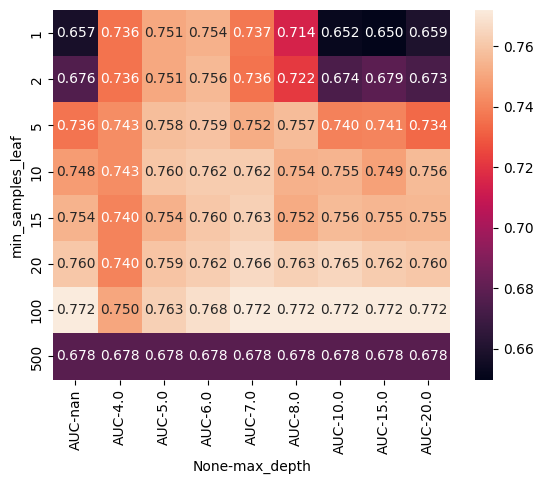

In [40]:
sns.heatmap(df_scores_pivot,annot=True, fmt='.3f')

In [41]:
dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=100)
dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
rf = RandomForestClassifier(n_estimators=50, random_state=1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [44]:
y_pred = rf.predict_proba(X_val)[:, 1]

In [45]:
scores = []
for n in range(1, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))

In [46]:
scores

[(1, 0.6293103448275862),
 (11, 0.7621055174891893),
 (21, 0.7861430854820524),
 (31, 0.7921741608534576),
 (41, 0.7934689679953412),
 (51, 0.794952730246447),
 (61, 0.7978644975033145),
 (71, 0.7989300804143382),
 (81, 0.801755114178448),
 (91, 0.8021454148958579),
 (101, 0.8055342163628929),
 (111, 0.8062962320492647),
 (121, 0.8069436356202064),
 (131, 0.8078977040405416),
 (141, 0.8088269914629462),
 (151, 0.8083127857558825),
 (161, 0.8083313715043305),
 (171, 0.8083933239991574),
 (181, 0.8084181049970883),
 (191, 0.8084428859950191)]

In [47]:
df_forest_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])
df_forest_scores.sort_values(by='auc', ascending=False)

,n_estimators,auc
14,141,0.808827
19,191,0.808443
18,181,0.808418
17,171,0.808393
16,161,0.808331
15,151,0.808313
13,131,0.807898
12,121,0.806944
11,111,0.806296
10,101,0.805534


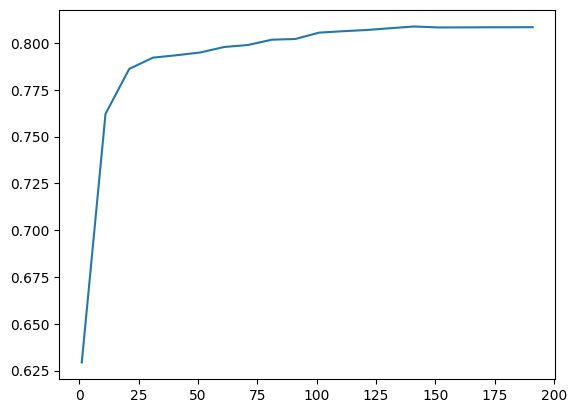

In [48]:
plt.plot(df_forest_scores.n_estimators, df_forest_scores.auc)

It is observable that AUC grows until n_estimators=100 and stagnates after that.

In [49]:
scores = []
for d in [5, 10, 15]:
    for n in range(1, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((d, n, auc))


In [50]:
columns = ['max_depth', 'n_estimators', 'auc']
df_forest_scores = pd.DataFrame(scores, columns=columns)

In [51]:
df_forest_scores.sort_values(by='auc', ascending=False).head(10)

,max_depth,n_estimators,auc
30,10,101,0.813641
28,10,81,0.813337
29,10,91,0.813312
31,10,111,0.812104
50,15,101,0.811463
36,10,161,0.811076
32,10,121,0.811057
54,15,141,0.810927
58,15,181,0.810778
39,10,191,0.810772


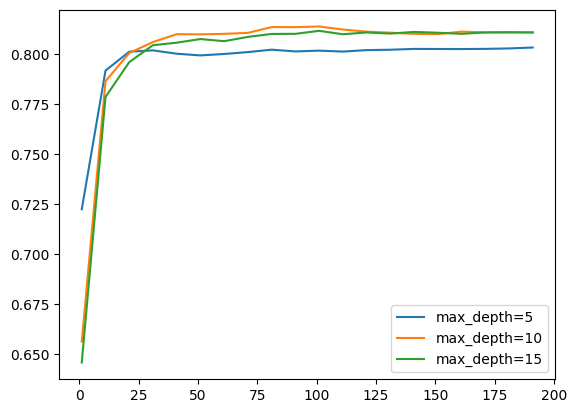

In [52]:
for d in [5, 10, 15]:
    df_subset = df_forest_scores[df_forest_scores.max_depth == d]

    plt.plot(df_subset.n_estimators, df_subset.auc, label='max_depth=%d' % d)

plt.legend()

we can see, that we reach the peak AUC at n_estimators = 80 and max_depth = 10

In [53]:
scores = []
for s in [1, 3, 5, 10, 20, 50]: # number of min_samples_leaf
    for n in range(1, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=10, min_samples_leaf = s, random_state=1, n_jobs=-1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((s, n, auc))


In [54]:
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_forest_scores = pd.DataFrame(scores, columns=columns)

In [55]:
colors = ['black', 'blue', 'orange', 'red', 'grey']
values = [1, 3, 5, 10, 50]

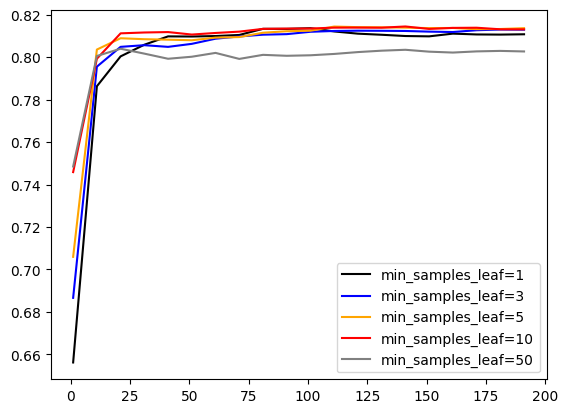

In [56]:
for s, col in zip(values, colors):
    df_subset = df_forest_scores[df_forest_scores.min_samples_leaf == s]
    plt.plot(df_subset.n_estimators, df_subset.auc, color = col, label='min_samples_leaf=%d' % s)

plt.legend()

In [57]:
df_forest_scores.sort_values(by='auc', ascending=False).head(10)

,min_samples_leaf,n_estimators,auc
74,10,141,0.814446
51,5,111,0.814403
52,5,121,0.814124
53,5,131,0.814037
72,10,121,0.813926
54,5,141,0.813901
71,10,111,0.813895
73,10,131,0.813876
77,10,171,0.813858
76,10,161,0.813777


In [58]:
rf = RandomForestClassifier(n_estimators=140, max_depth=10, min_samples_leaf=10 , random_state=1)
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.8142292490118577

In [67]:
%pip install xgboost

  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.3.0-py3-none-win_amd64.whl (69.5 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\ruste\OneDrive\Рабочий стол\stuff\hmm\.venv\Scripts\python.exe -m pip install --upgrade pip


In [68]:
import xgboost as xgb

In [70]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [93]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'nthread': 20,
    'seed': 1,
    'verbosity': 2
}

model = xgb.train(xgb_params, dtrain, num_boost_round=10)

In [91]:
y_pred = model.predict(dval)

In [92]:
roc_auc_score(y_val, y_pred)

0.8027711350936102

In [97]:
%%capture output

watchlist = [(dtrain, 'train'), (dval, 'val')]
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'nthread': 20,
    'seed': 1,
    'verbosity': 2,
    'eval_metric': 'auc'
}

model = xgb.train(xgb_params, dtrain, verbose_eval=5, num_boost_round=200, evals=watchlist)

In [99]:
s = output.stdout
print(s)

[0]	train-auc:0.87076	val-auc:0.73827
[5]	train-auc:0.93170	val-auc:0.80437
[10]	train-auc:0.95017	val-auc:0.80560
[15]	train-auc:0.96594	val-auc:0.80397
[20]	train-auc:0.97557	val-auc:0.80640
[25]	train-auc:0.98227	val-auc:0.80571
[30]	train-auc:0.98667	val-auc:0.80651
[35]	train-auc:0.99132	val-auc:0.80820
[40]	train-auc:0.99339	val-auc:0.80473
[45]	train-auc:0.99447	val-auc:0.80521
[50]	train-auc:0.99606	val-auc:0.80606
[55]	train-auc:0.99726	val-auc:0.80475
[60]	train-auc:0.99832	val-auc:0.80395
[65]	train-auc:0.99893	val-auc:0.80245
[70]	train-auc:0.99939	val-auc:0.80345
[75]	train-auc:0.99960	val-auc:0.80204
[80]	train-auc:0.99971	val-auc:0.79958
[85]	train-auc:0.99985	val-auc:0.79668
[90]	train-auc:0.99994	val-auc:0.79567
[95]	train-auc:0.99995	val-auc:0.79577
[100]	train-auc:0.99997	val-auc:0.79523
[105]	train-auc:0.99998	val-auc:0.79562
[110]	train-auc:0.99999	val-auc:0.79546
[115]	train-auc:1.00000	val-auc:0.79469
[120]	train-auc:1.00000	val-auc:0.79453
[125]	train-auc:1.0000

In [101]:
line = s.split('\n')[0]

In [104]:
num_iter, train_auc, val_auc = line.split('\t')

In [107]:
int(num_iter.strip('[]'))

0

In [109]:
float(train_auc.split(':')[1])

0.87076

In [110]:
float(val_auc.split(':')[1])

0.73827

In [113]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        iter_line, train_line, val_line = line.split('\t')

        it = int(iter_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))

    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns = columns)
    return df_results

In [114]:
parse_xgb_output(output)

,num_iter,train_auc,val_auc
0,0,0.87076,0.73827
1,5,0.93170,0.80437
2,10,0.95017,0.80560
3,15,0.96594,0.80397
4,20,0.97557,0.80640
5,25,0.98227,0.80571
6,30,0.98667,0.80651
7,35,0.99132,0.80820
8,40,0.99339,0.80473
9,45,0.99447,0.80521


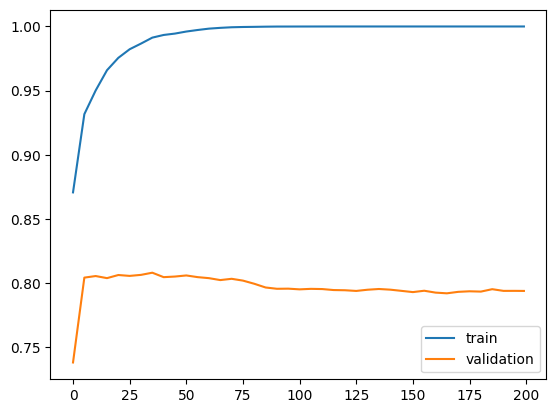

In [116]:
df_score = parse_xgb_output(output)
plt.plot(df_score.num_iter, df_score.train_auc, label='train')
plt.plot(df_score.num_iter, df_score.val_auc, label='validation')

plt.legend()